# titanic dataset

In [270]:
import pandas as pd
import seaborn as sns  
import matplotlib.pyplot as plt
import numpy as np

In [271]:
file_loc = "titanic_train.csv"
data = pd.read_csv(file_loc)
pd.set_option("display.max_rows",None)


In [272]:
print(data.isna().sum()) 
print(data.columns)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [273]:
data =data.drop(["Cabin"],axis=1) 
data =data.drop(["PassengerId","Name","Ticket","Embarked"],axis=1) 

data = pd.get_dummies(data, columns=["Sex"], drop_first=True)
from sklearn.preprocessing import LabelEncoder

for col in data.select_dtypes("bool"):
    L_e =LabelEncoder()
    data[col] =L_e.fit_transform(data[col])

print(data.head(5))




   Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male
0         0       3  22.0      1      0   7.2500         1
1         1       1  38.0      1      0  71.2833         0
2         1       3  26.0      0      0   7.9250         0
3         1       1  35.0      1      0  53.1000         0
4         0       3  35.0      0      0   8.0500         1


In [274]:
data =data.fillna(data["Age"].median())
print(data.isna().sum()) 


data_corr = data.corr()["Survived"].sort_values(ascending=True) 
print(data_corr)

Survived    0
Pclass      0
Age         0
SibSp       0
Parch       0
Fare        0
Sex_male    0
dtype: int64
Sex_male   -0.543351
Pclass     -0.338481
Age        -0.064910
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Survived    1.000000
Name: Survived, dtype: float64


<Figure size 1000x500 with 0 Axes>

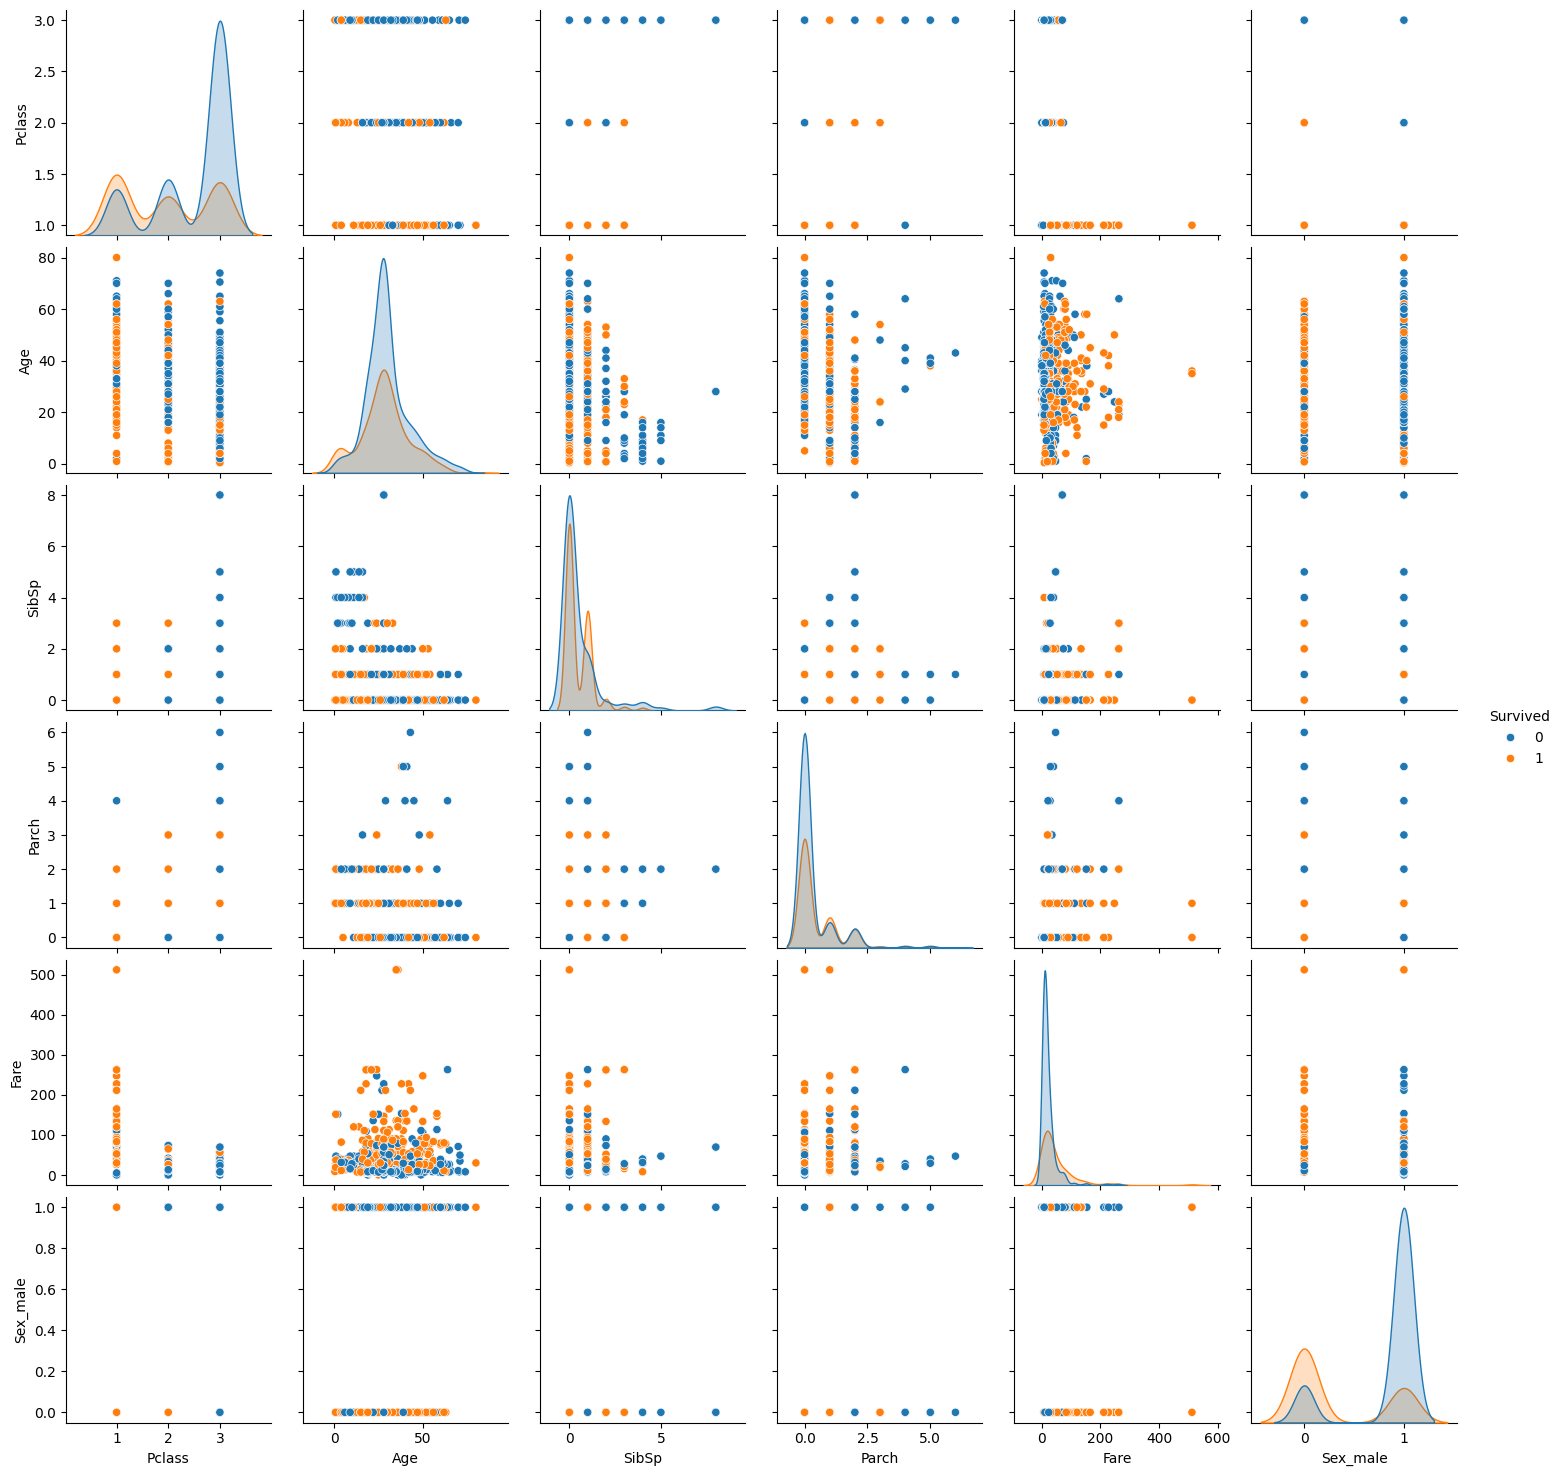

In [275]:
plt.figure(figsize=(10,5))
sns.pairplot(data=data,hue="Survived")
plt.show()

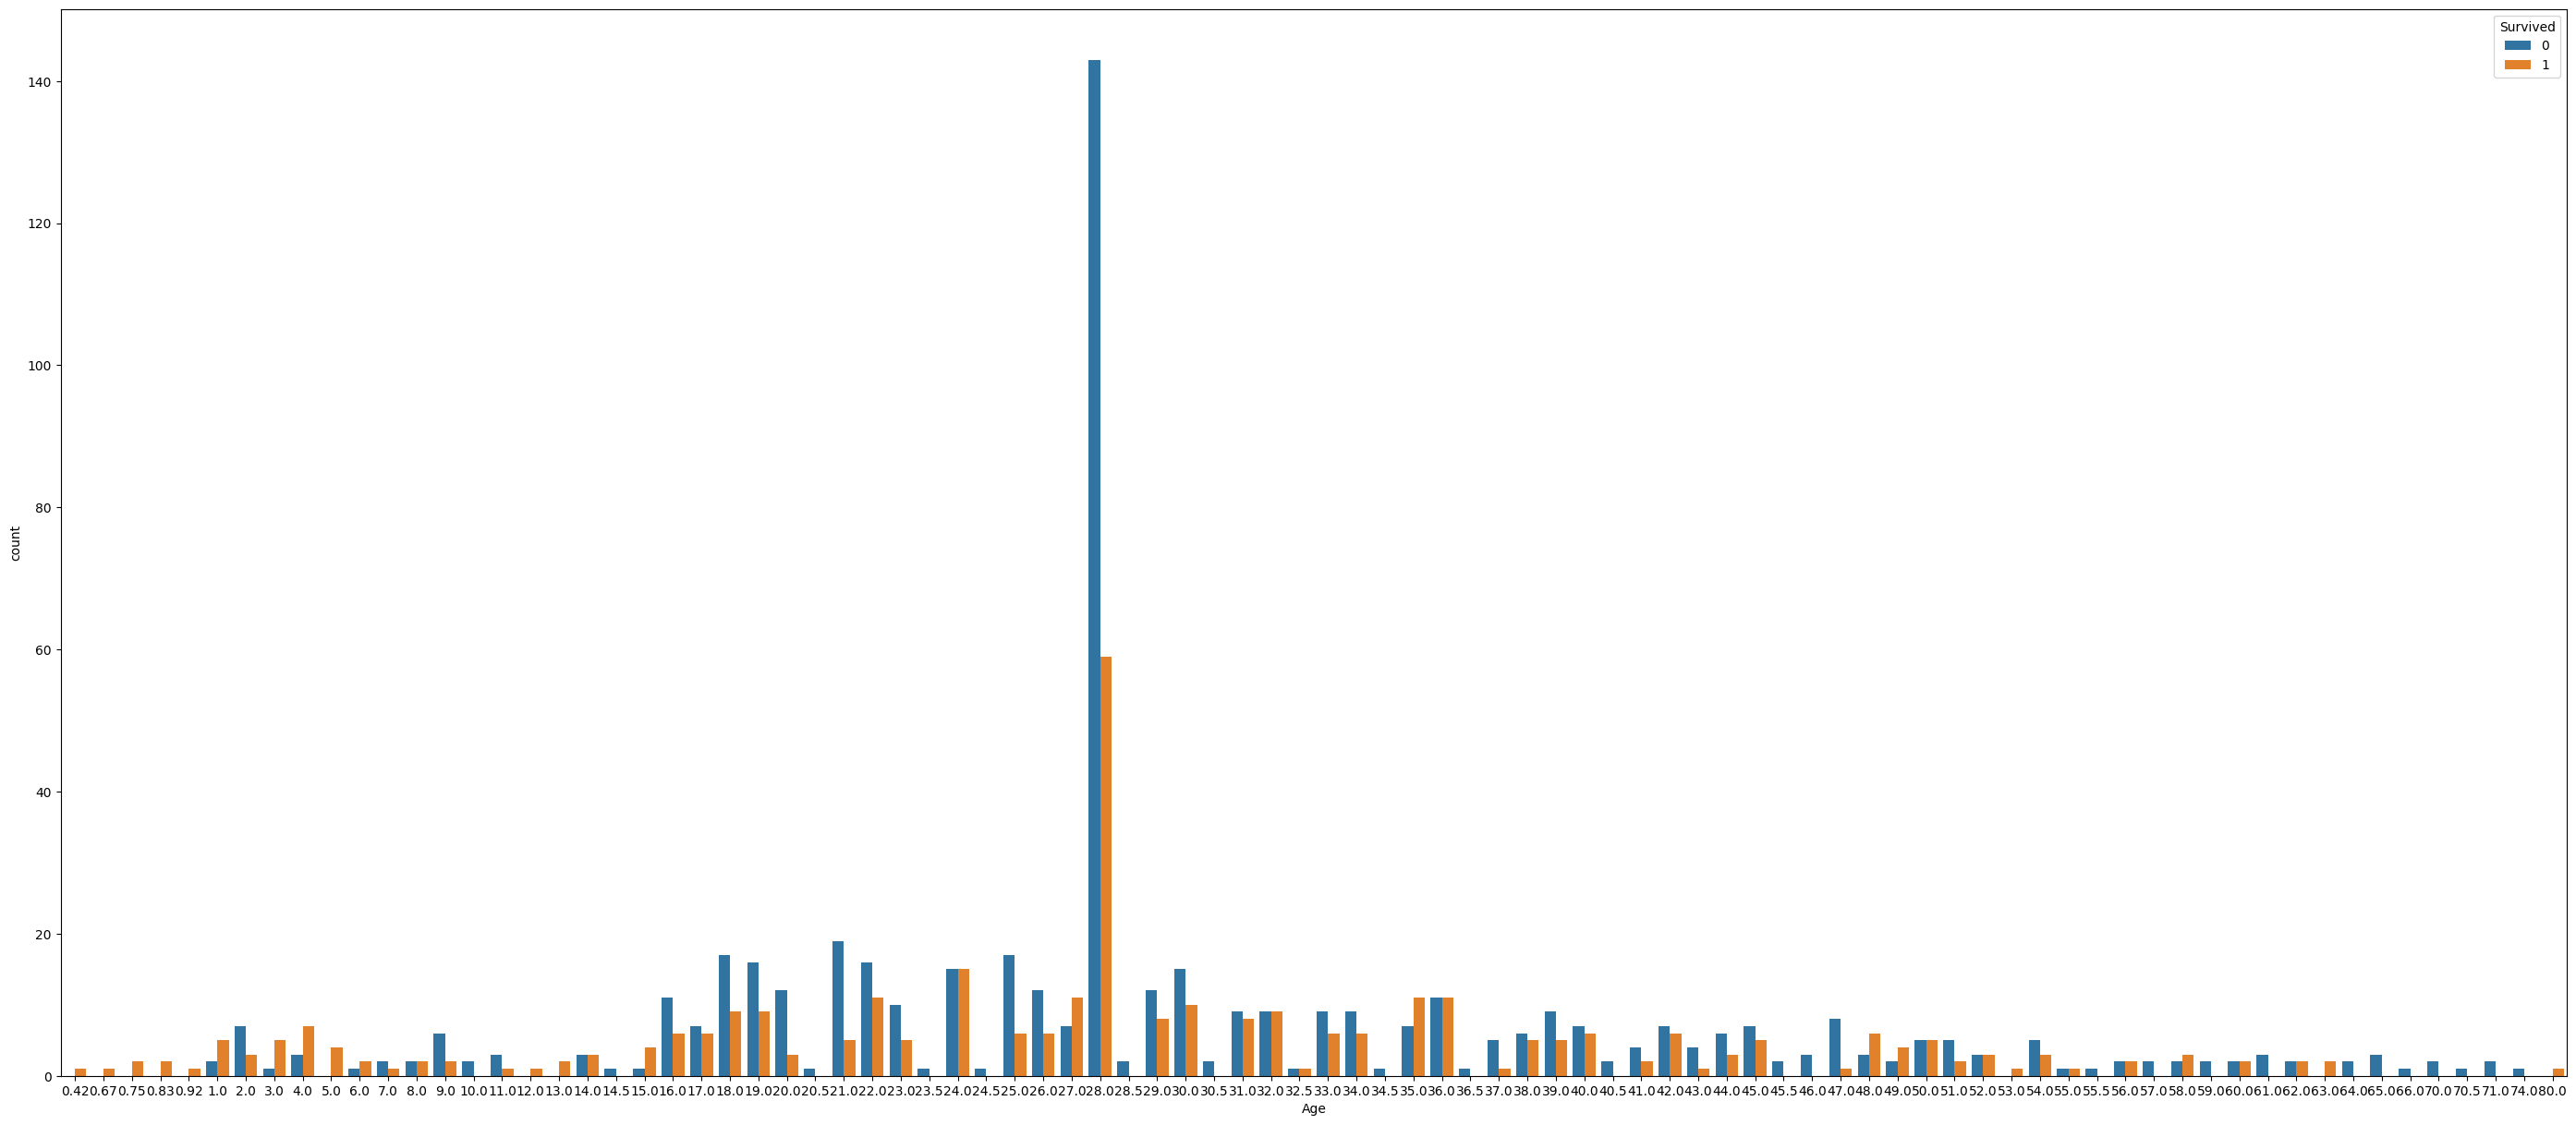

In [276]:
plt.figure(figsize=(35,15))
sns.countplot(data=data,x="Age",hue="Survived")
plt.show()

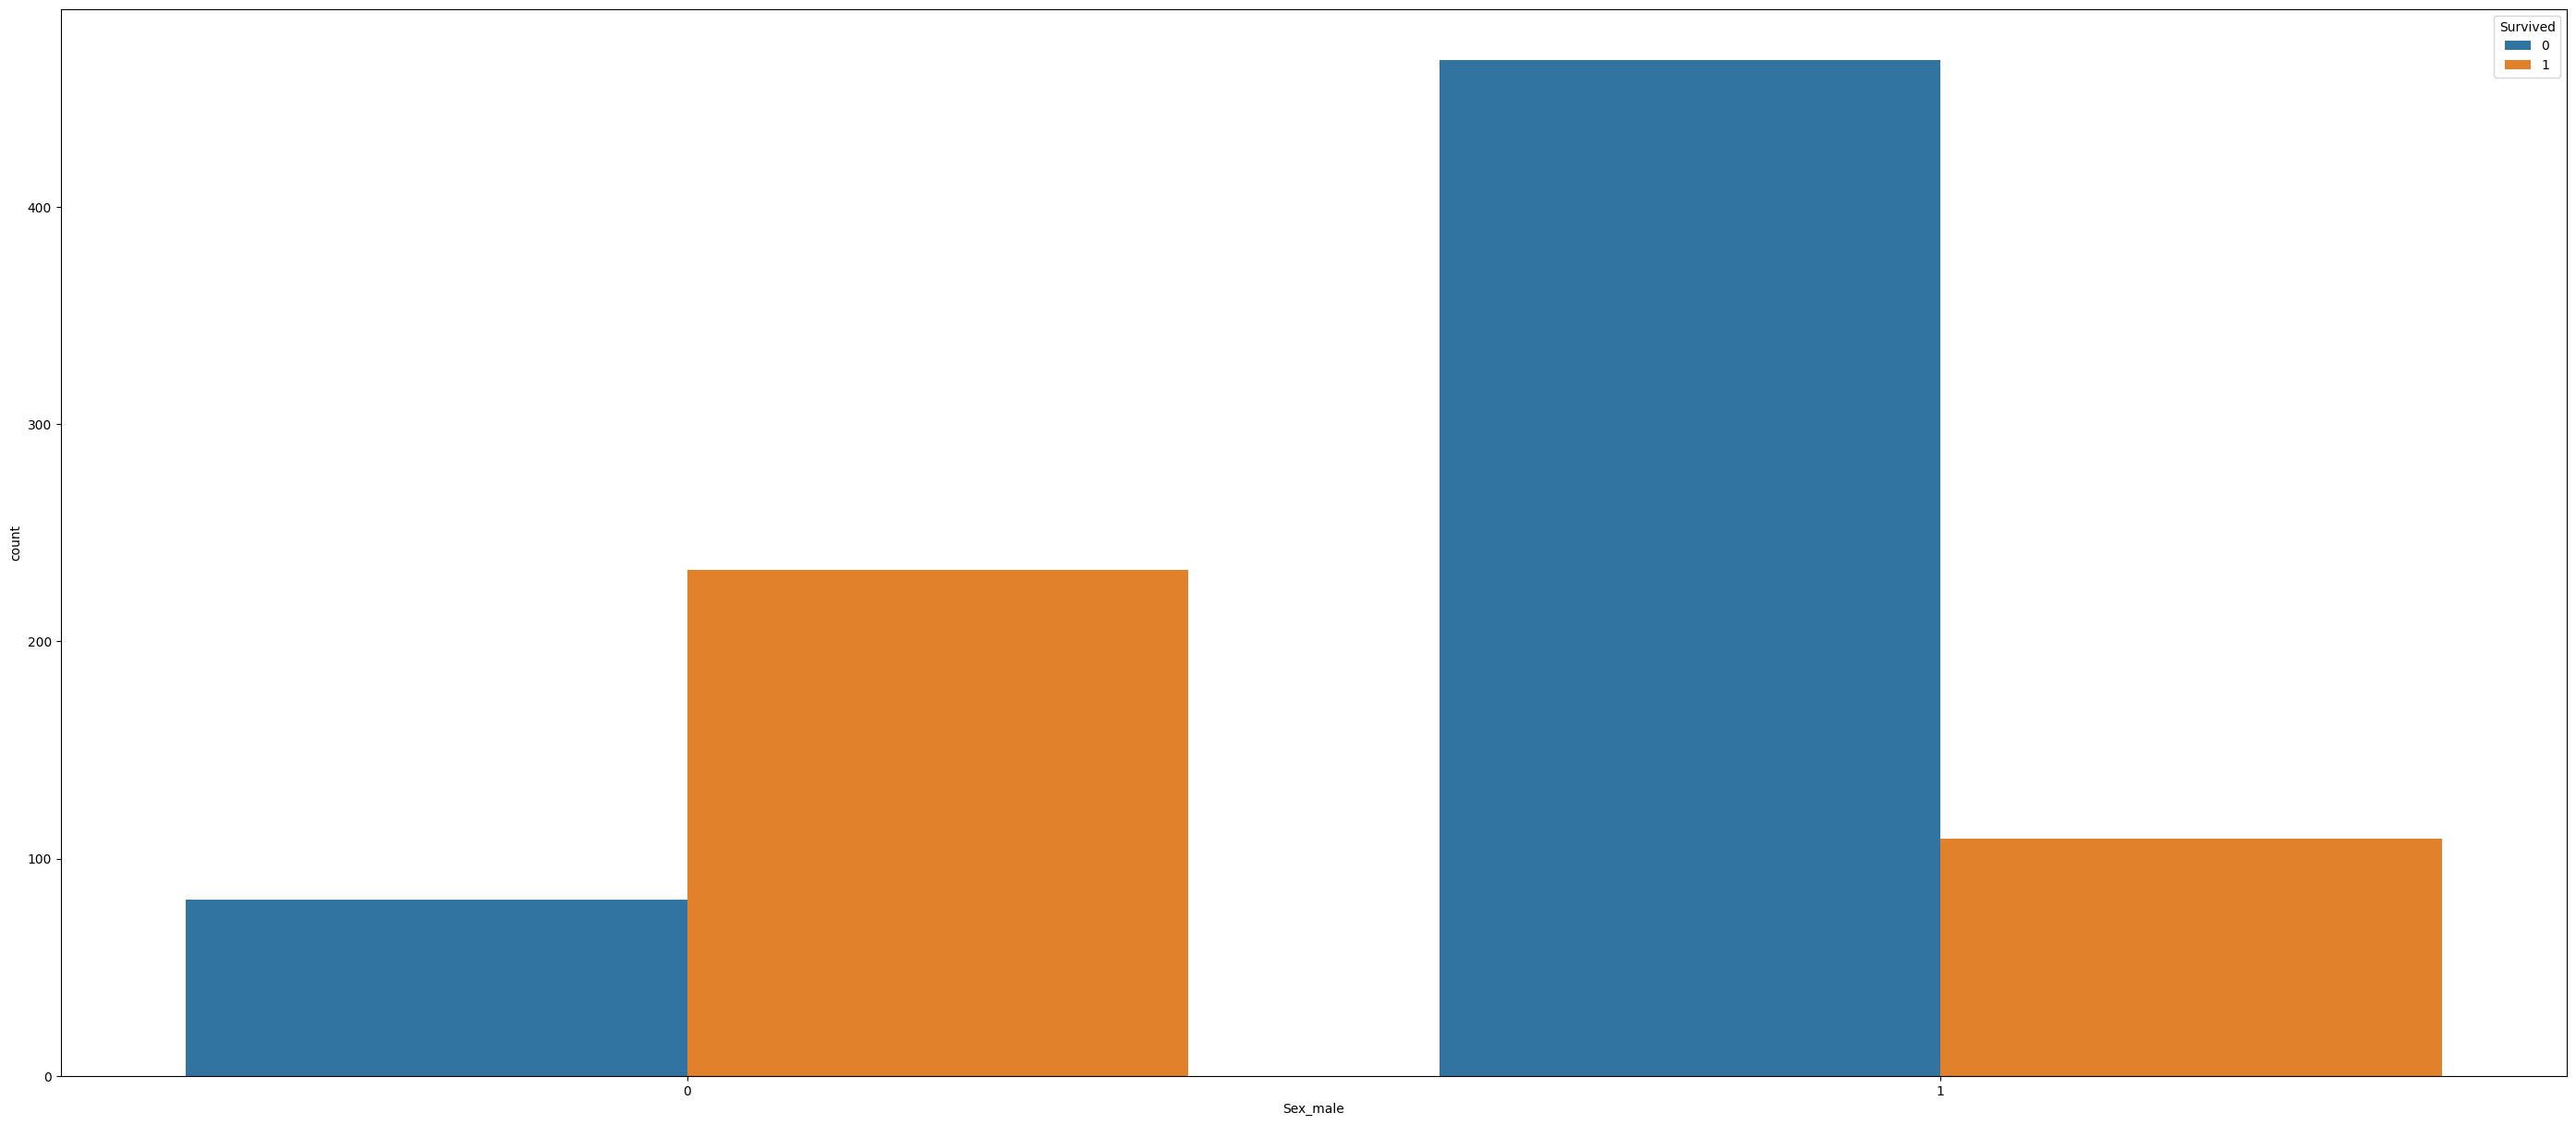

In [283]:
plt.figure(figsize=(35,15))
sns.countplot(data=data,x="Sex_male",hue="Survived")
plt.show()

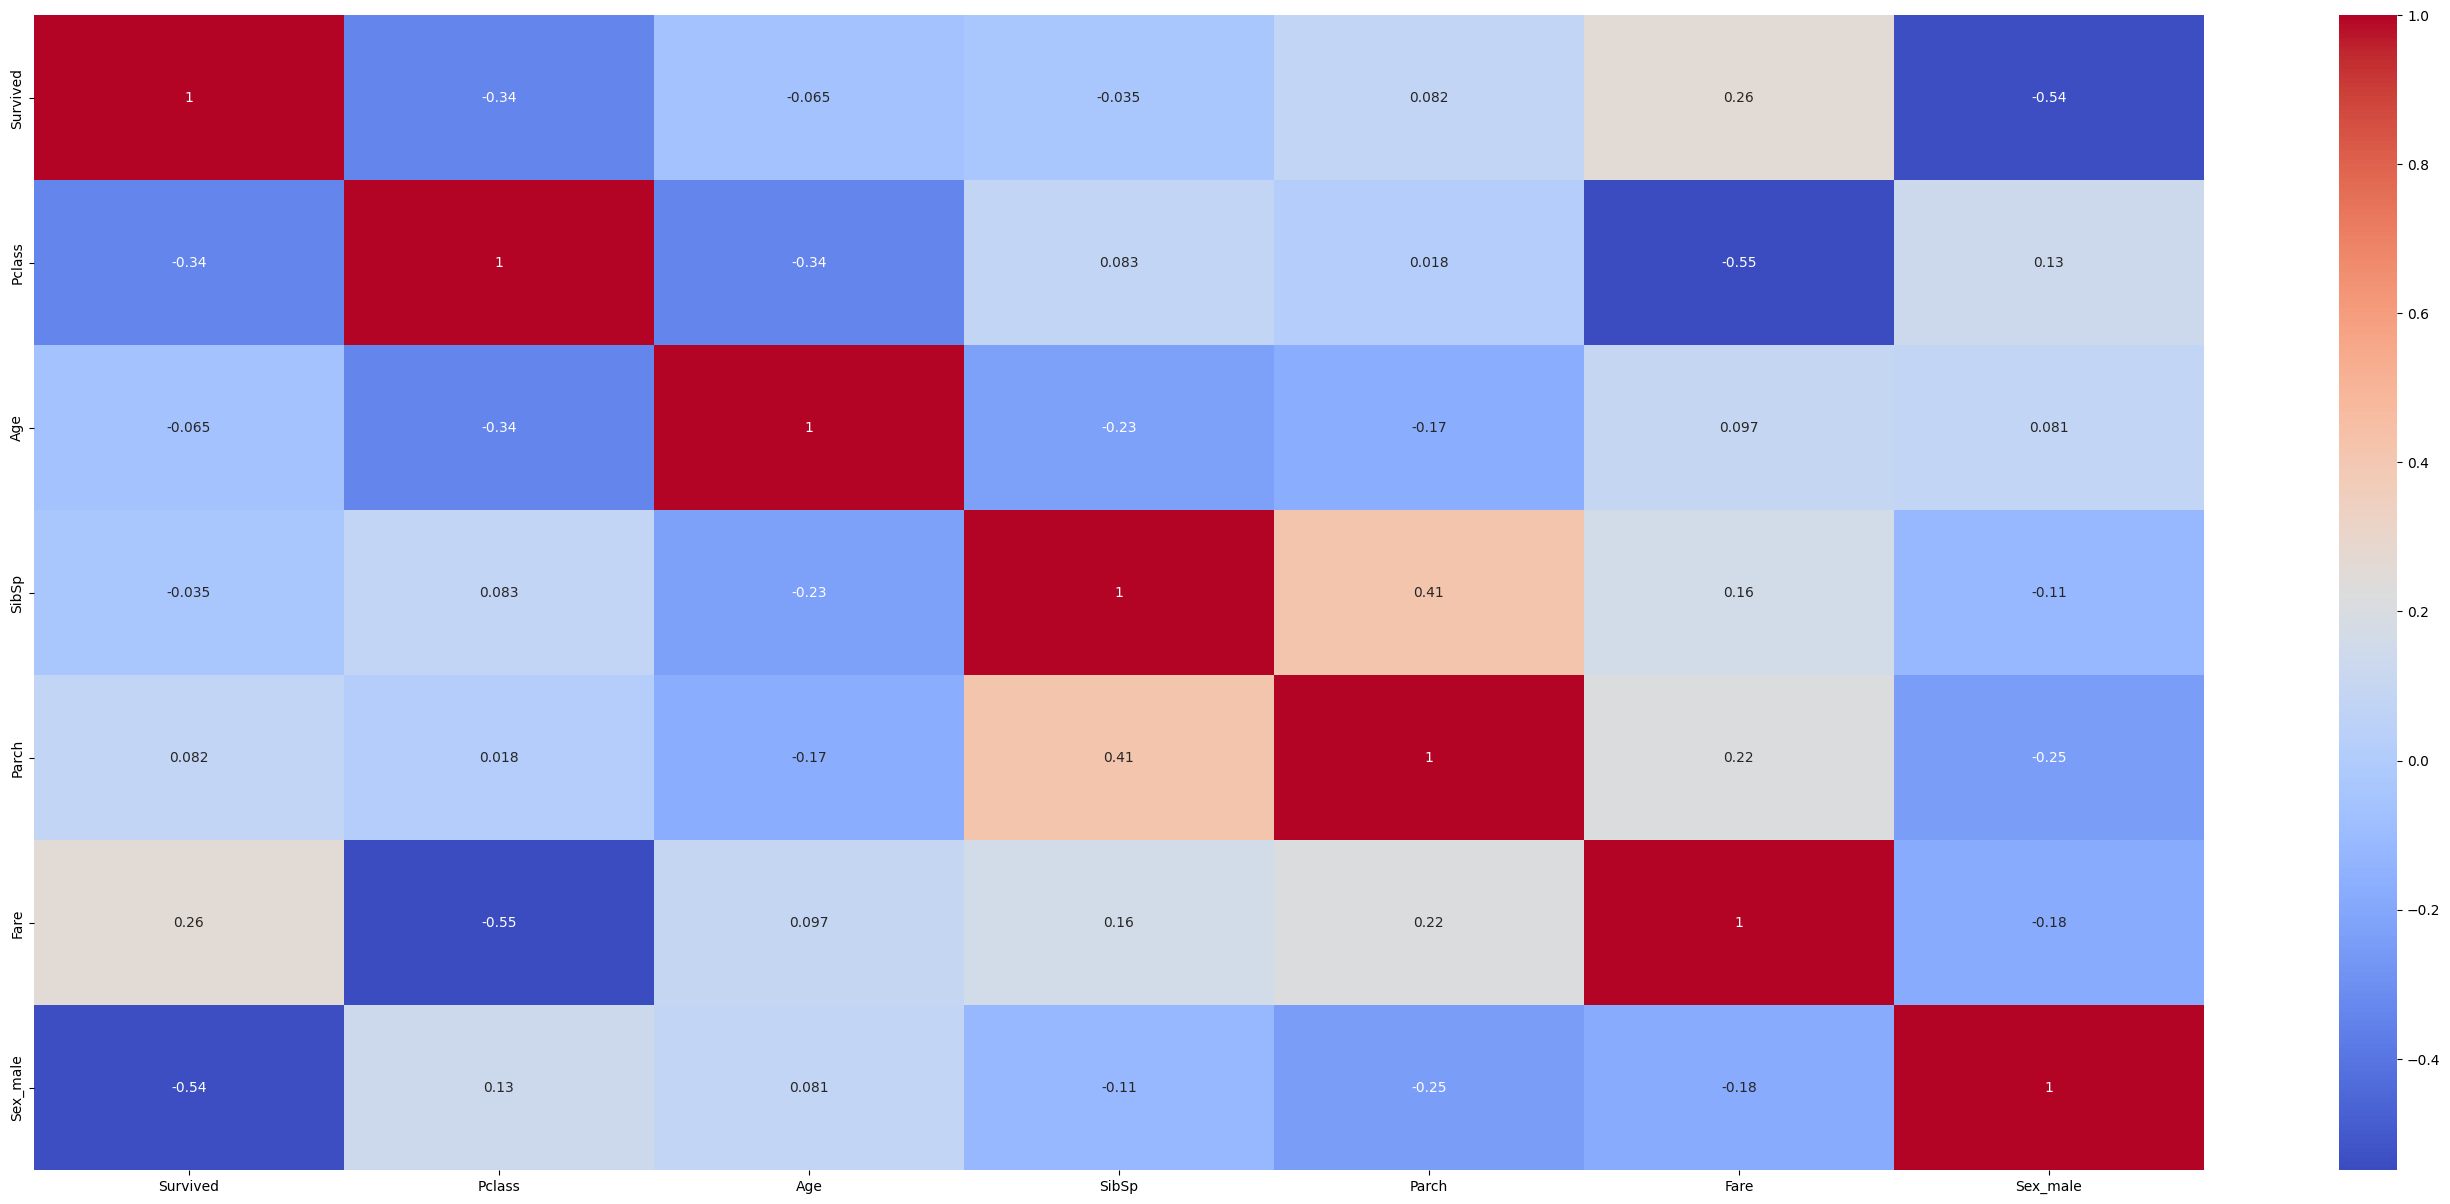

In [284]:
plt.figure(figsize=(35,15))
sns.heatmap(data=data.corr(),annot=True,cmap="coolwarm")
plt.show()

In [285]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

In [286]:
X =data.drop(["Survived"],axis=1)
y =data["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)



In [ ]:
Pipeline_ =Pipeline([
    ('model',RandomForestClassifier())
])

param ={
    'model__n_estimators':[200,300,400],
    'model__max_depth':[5,10]
}

grid =GridSearchCV(
    Pipeline_,
    param,
    verbose=True,
    cv =5
)

grid.fit(X_train,y_train)
prediction =grid.predict(X_test)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [288]:
print(round(accuracy_score(y_test,prediction),2))
print(round(precision_score(y_test,prediction),2))
print(classification_report(y_test,prediction))

0.82
0.87
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       175
           1       0.87      0.67      0.75       120

    accuracy                           0.82       295
   macro avg       0.84      0.80      0.81       295
weighted avg       0.83      0.82      0.82       295



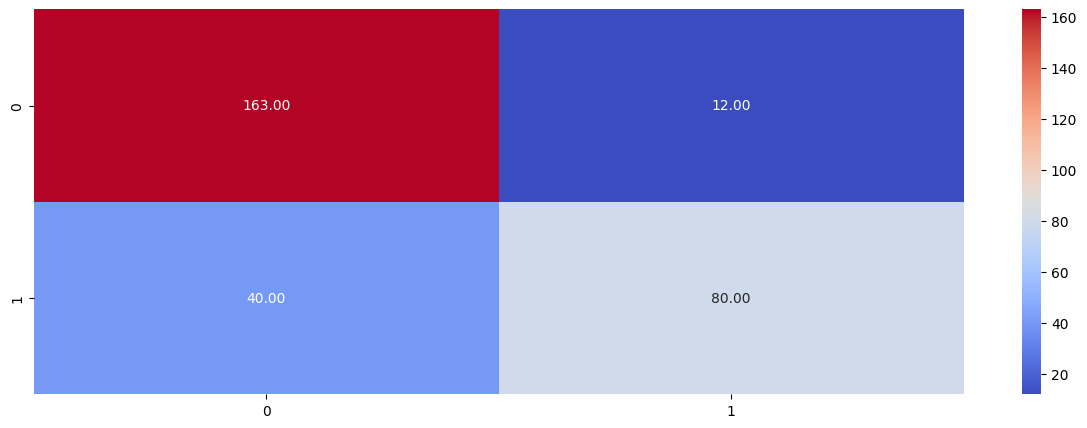

In [289]:
cf =confusion_matrix(y_test,prediction)
plt.figure(figsize=(15,5))
sns.heatmap(data=cf,annot=True,cmap="coolwarm",fmt=".2f")
plt.show()